In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mping
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout

In [18]:
train=pd. read_csv('/kaggle/input/datasets/ishitamishra23/mnist-dataset-cnn-implementation-from-scratch/train.csv')
test=pd. read_csv('/kaggle/input/datasets/ishitamishra23/mnist-dataset-cnn-implementation-from-scratch/test.csv')

In [19]:
train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [20]:
test.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
train['label'].value_counts().sort_index()

label
0    4132
1    4684
2    4177
3    4351
4    4072
5    3795
6    4137
7    4401
8    4063
9    4188
Name: count, dtype: int64

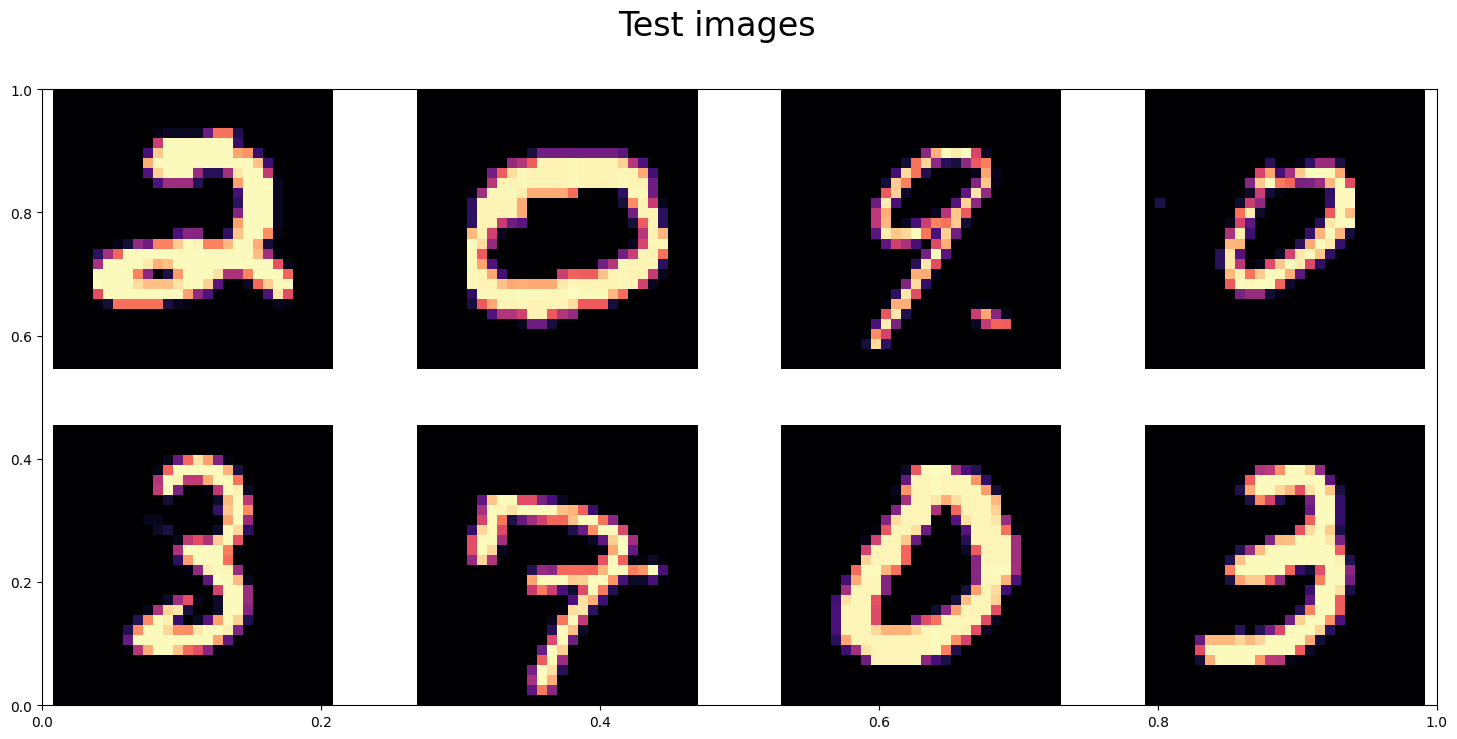

In [22]:
fig, ax = plt.subplots(figsize=(18, 8))
for ind, row in test.iloc[:8, :].iterrows():
    plt.subplot(2, 4, ind+1)
    img = row.to_numpy()[:].reshape(28, 28)
    fig.suptitle('Test images', fontsize=24)
    plt.axis('off')
    plt.imshow(img, cmap='magma')

In [23]:
X = train.iloc[:, 1:].to_numpy()
y = train['label'].to_numpy()

test = test.loc[:, :].to_numpy()

for i in (X, y, test):
    print(i.shape)

(42000, 784)
(42000,)
(28000, 784)


In [24]:
X = X / 255.0
test = test / 255.0

In [26]:
print(X.shape)
print(test.shape)

X = X.reshape(-1,28,28,1)
test= test.reshape(-1,28,28,1)

print(X.shape)
print(test.shape)

(42000, 784)
(28000, 784)
(42000, 28, 28, 1)
(28000, 28, 28, 1)


In [25]:
print(y.shape)
print(y[0])
y_enc = to_categorical(y, num_classes = 10)

print(y_enc.shape)
print(y_enc[0])


(42000,)
1
(42000, 10)
[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]


In [27]:
#train test split
#random seed
randm_seed=2
X_train, X_val, y_train_enc, y_val_enc=train_test_split(X, y_enc, test_size=0.3)
for i in [X_train, y_train_enc, X_val, y_val_enc]:
    print(i.shape)

(29400, 28, 28, 1)
(29400, 10)
(12600, 28, 28, 1)
(12600, 10)


[0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]


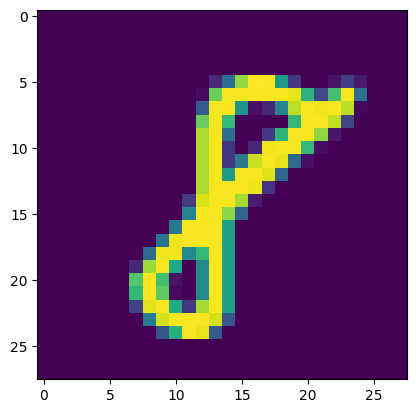

In [28]:
g = plt.imshow(X_train[0][:,:,0])
print(y_train_enc[0])

In [32]:
INPUT_SHAPE = (28,28,1)
OUTPUT_SHAPE = 10
BATCH_SIZE = 128
EPOCHS = 10
VEROOSE = 2

In [38]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout

model = Sequential()

model.add(Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=INPUT_SHAPE))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(10, activation='softmax'))

In [68]:
model.compile(optimizer='adam',
             loss='categorical_crossentropy',
             metrics=['accuracy'])
             

In [48]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 232,650 (908.79 KB)

 Trainable params: 232,650 (908.79 KB)

 Non-trainable params: 0 (0.00 B)

In [69]:
history = model.fit(
    X_train,
    y_train_enc,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2,
    validation_data=(X_val, y_val_enc)
)

Epoch 1/10
230/230 - 15s - 66ms/step - accuracy: 0.8537 - loss: 0.4601 - val_accuracy: 0.9718 - val_loss: 0.0939
Epoch 2/10
230/230 - 12s - 52ms/step - accuracy: 0.9657 - loss: 0.1161 - val_accuracy: 0.9815 - val_loss: 0.0614
Epoch 3/10
230/230 - 12s - 51ms/step - accuracy: 0.9763 - loss: 0.0808 - val_accuracy: 0.9837 - val_loss: 0.0578
Epoch 4/10
230/230 - 13s - 57ms/step - accuracy: 0.9814 - loss: 0.0611 - val_accuracy: 0.9867 - val_loss: 0.0464
Epoch 5/10
230/230 - 13s - 57ms/step - accuracy: 0.9857 - loss: 0.0475 - val_accuracy: 0.9888 - val_loss: 0.0394
Epoch 6/10
230/230 - 12s - 51ms/step - accuracy: 0.9878 - loss: 0.0406 - val_accuracy: 0.9901 - val_loss: 0.0368
Epoch 7/10
230/230 - 12s - 51ms/step - accuracy: 0.9901 - loss: 0.0330 - val_accuracy: 0.9901 - val_loss: 0.0362
Epoch 8/10
230/230 - 12s - 52ms/step - accuracy: 0.9897 - loss: 0.0319 - val_accuracy: 0.9875 - val_loss: 0.0443
Epoch 9/10
230/230 - 12s - 53ms/step - accuracy: 0.9908 - loss: 0.0277 - val_accuracy: 0.9907 - 

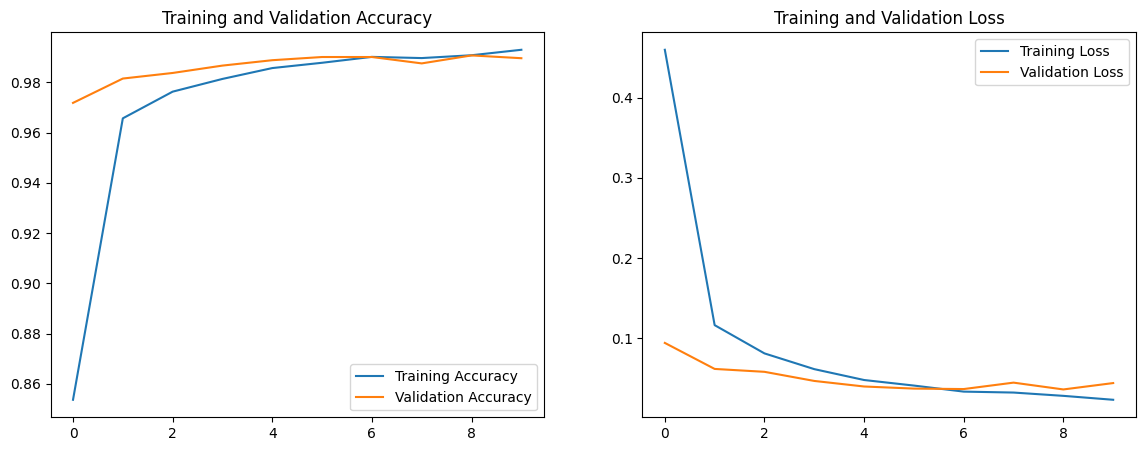

In [70]:
plt.figure(figsize=(14,5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label ='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.savefig('./foo.png')
plt.show()

In [73]:
model.evaluate(X_val, y_val_enc, verbose=False)

[0.04371631518006325, 0.9896031618118286]

In [74]:
y_pred_enc = model.predict(X_val)

y_act = [np.argmax(i) for i in y_val_enc]

y_pred = [np.argmax(i) for i in y_pred_enc]

print(y_pred_enc[0])
print(y_pred[0])

394/394 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
[8.7157321e-13 9.9999994e-01 7.3119705e-12 2.2166767e-11 2.3986924e-11
 2.8871224e-12 2.8491630e-12 8.0248999e-09 6.3621997e-11 1.1657978e-12]
1


In [75]:
print(classification_report(y_act, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1232
           1       0.99      0.99      0.99      1416
           2       1.00      0.98      0.99      1268
           3       1.00      0.98      0.99      1286
           4       0.99      0.99      0.99      1252
           5       0.99      0.99      0.99      1126
           6       0.99      0.99      0.99      1260
           7       0.98      1.00      0.99      1266
           8       0.98      0.99      0.99      1236
           9       0.98      0.99      0.99      1258

    accuracy                           0.99     12600
   macro avg       0.99      0.99      0.99     12600
weighted avg       0.99      0.99      0.99     12600



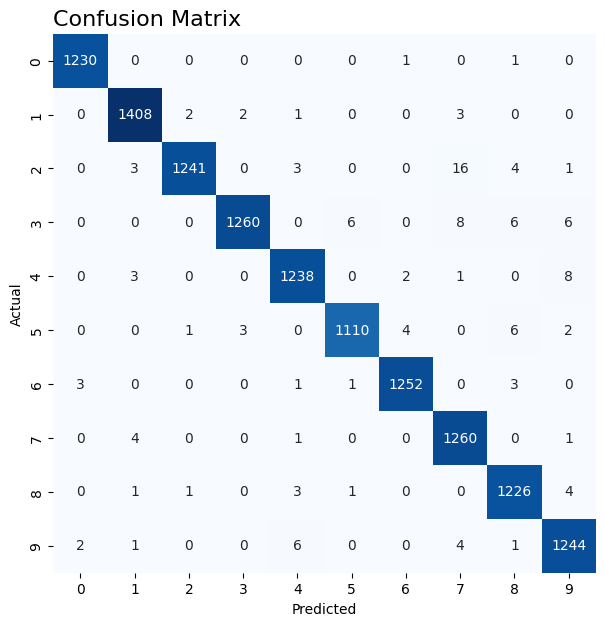

In [78]:
fig, ax = plt.subplots(figsize=(7, 7))
sns.heatmap(confusion_matrix(y_act, y_pred), annot=True,
           cbar=False, fmt='1d', cmap='Blues', ax=ax)
ax.set_title('Confusion Matrix', loc='left', fontsize=16)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.show()

In [80]:
y_pred_enc = model.predict(test)
y_pred = [np.argmax(i) for i in y_pred_enc]
print(y_pred_enc[0])
print(y_pred[0])

875/875 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step
[1.4087117e-07 8.5911772e-08 9.9999815e-01 4.5373744e-07 2.7489337e-08
 8.4949886e-12 2.1170257e-10 9.7647353e-07 8.8322132e-08 5.9951000e-09]
2


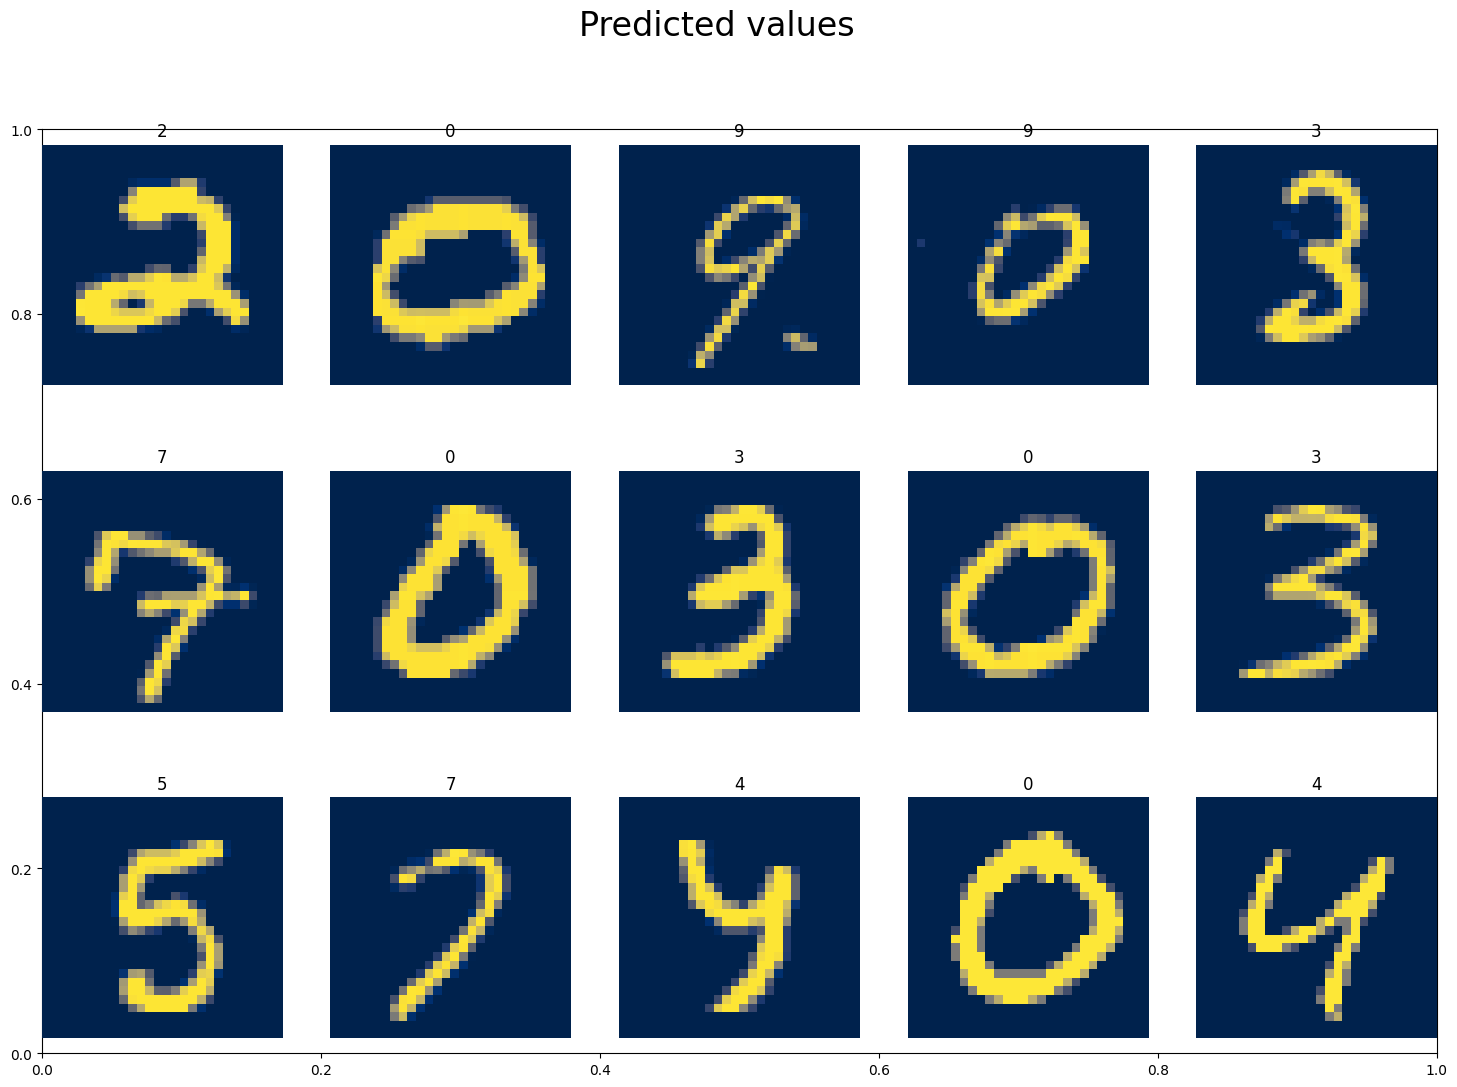

In [81]:
fig, ax = plt.subplots(figsize=(18, 12))
for ind, row in enumerate(test[:15]):
    plt.subplot(3, 5, ind+1)
    plt.title(y_pred[ind])
    img = row.reshape(28, 28)
    fig.suptitle('Predicted values', fontsize=24)
    plt.axis('off')
    plt.imshow(img, cmap='cividis')